In [62]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Domain Analysis
 Build a predictive model to estimate student performance based on the provided attributes (e.g., TA's native language,instructor, course, semester,and
 class size)

In [63]:
df= pd.read_csv('tae.csv',header=None)
df

,0,1,2,3,4,5
0,1,23,3,1,19,3
1,2,15,3,1,17,3
2,1,23,3,2,49,3
3,1,5,2,2,33,3
4,2,7,11,2,55,3
...,...,...,...,...,...,...
146,2,3,2,2,26,1
147,2,10,3,2,12,1
148,1,18,7,2,48,1
149,2,22,1,2,51,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       151 non-null    int64
 1   1       151 non-null    int64
 2   2       151 non-null    int64
 3   3       151 non-null    int64
 4   4       151 non-null    int64
 5   5       151 non-null    int64
dtypes: int64(6)
memory usage: 7.2 KB


## EDA Process

In [7]:
 df.rename(columns={
     df.columns[0] : 'Native_Teacher' , 
     df.columns[1] : 'instructor' ,
     df.columns[2] : 'course' , 
     df.columns[3] : 'semester',
     df.columns[4] : 'num_of_std',
     df.columns[5] : 'class_attribute'},inplace=True)

In [8]:
df

,Native_Teacher,instructor,course,semester,num_of_std,class_attribute
0,1,23,3,1,19,3
1,2,15,3,1,17,3
2,1,23,3,2,49,3
3,1,5,2,2,33,3
4,2,7,11,2,55,3
...,...,...,...,...,...,...
146,2,3,2,2,26,1
147,2,10,3,2,12,1
148,1,18,7,2,48,1
149,2,22,1,2,51,1


In [9]:
df.describe()

,Native_Teacher,instructor,course,semester,num_of_std,class_attribute
count,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000
mean,1.807947,13.642384,8.105960,1.847682,27.867550,2.019868
std,0.395225,6.825779,7.023914,0.360525,12.893758,0.820327
min,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000
25%,2.000000,8.000000,3.000000,2.000000,19.000000,1.000000
50%,2.000000,13.000000,4.000000,2.000000,27.000000,2.000000
75%,2.000000,20.000000,15.000000,2.000000,37.000000,3.000000
max,2.000000,25.000000,26.000000,2.000000,66.000000,3.000000


In [10]:
df.isnull().sum()

Native_Teacher     0
instructor         0
course             0
semester           0
num_of_std         0
class_attribute    0
dtype: int64

In [11]:
df['Native_Teacher'].value_counts()

Native_Teacher
2    122
1     29
Name: count, dtype: int64

In [12]:
df['instructor'].value_counts()

instructor
23    17
13    14
22    12
7     11
15     8
10     8
9      8
18     8
6      8
14     8
5      6
8      5
20     5
1      4
2      4
16     4
25     4
17     4
11     3
21     2
4      2
12     2
3      2
24     1
19     1
Name: count, dtype: int64

In [13]:
df['course'].value_counts()

course
3     45
2     16
1     14
17    10
15    10
11     9
7      7
5      5
8      4
22     3
25     3
21     3
9      3
13     3
16     3
6      2
18     2
19     1
14     1
12     1
23     1
26     1
24     1
20     1
4      1
10     1
Name: count, dtype: int64

In [14]:
df['semester'].value_counts()

semester
2    128
1     23
Name: count, dtype: int64

In [15]:
df['num_of_std'].value_counts()

num_of_std
19    11
20    11
42     7
27     7
17     6
29     6
38     6
37     6
31     6
10     6
24     5
30     4
13     4
21     4
11     4
48     3
23     3
22     3
25     3
36     3
39     3
51     3
43     2
9      2
58     2
55     2
33     2
49     2
46     2
28     2
45     2
18     2
14     2
15     2
12     2
35     1
34     1
32     1
66     1
3      1
7      1
54     1
16     1
44     1
5      1
26     1
Name: count, dtype: int64

In [16]:
df['class_attribute'].value_counts()

class_attribute
3    52
2    50
1    49
Name: count, dtype: int64

In [17]:
df.columns

Index(['Native_Teacher', 'instructor', 'course', 'semester', 'num_of_std',
       'class_attribute'],
      dtype='object')

In [18]:
df.dtypes

Native_Teacher     int64
instructor         int64
course             int64
semester           int64
num_of_std         int64
class_attribute    int64
dtype: object

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Native_Teacher   151 non-null    int64
 1   instructor       151 non-null    int64
 2   course           151 non-null    int64
 3   semester         151 non-null    int64
 4   num_of_std       151 non-null    int64
 5   class_attribute  151 non-null    int64
dtypes: int64(6)
memory usage: 7.2 KB


In [20]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
146    False
147    False
148    False
149    False
150    False
Length: 151, dtype: bool

In [21]:
print(df.duplicated().sum())

41


 ## Data Visualization

In [22]:
df

,Native_Teacher,instructor,course,semester,num_of_std,class_attribute
0,1,23,3,1,19,3
1,2,15,3,1,17,3
2,1,23,3,2,49,3
3,1,5,2,2,33,3
4,2,7,11,2,55,3
...,...,...,...,...,...,...
146,2,3,2,2,26,1
147,2,10,3,2,12,1
148,1,18,7,2,48,1
149,2,22,1,2,51,1


<Axes: xlabel='Native_Teacher', ylabel='count'>

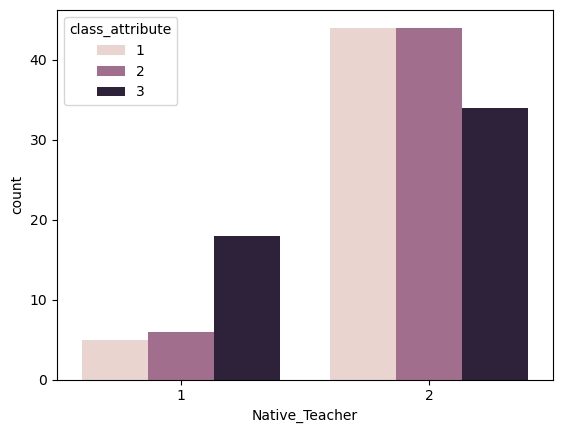

In [23]:
sns.countplot(x='Native_Teacher',hue='class_attribute',data=df)

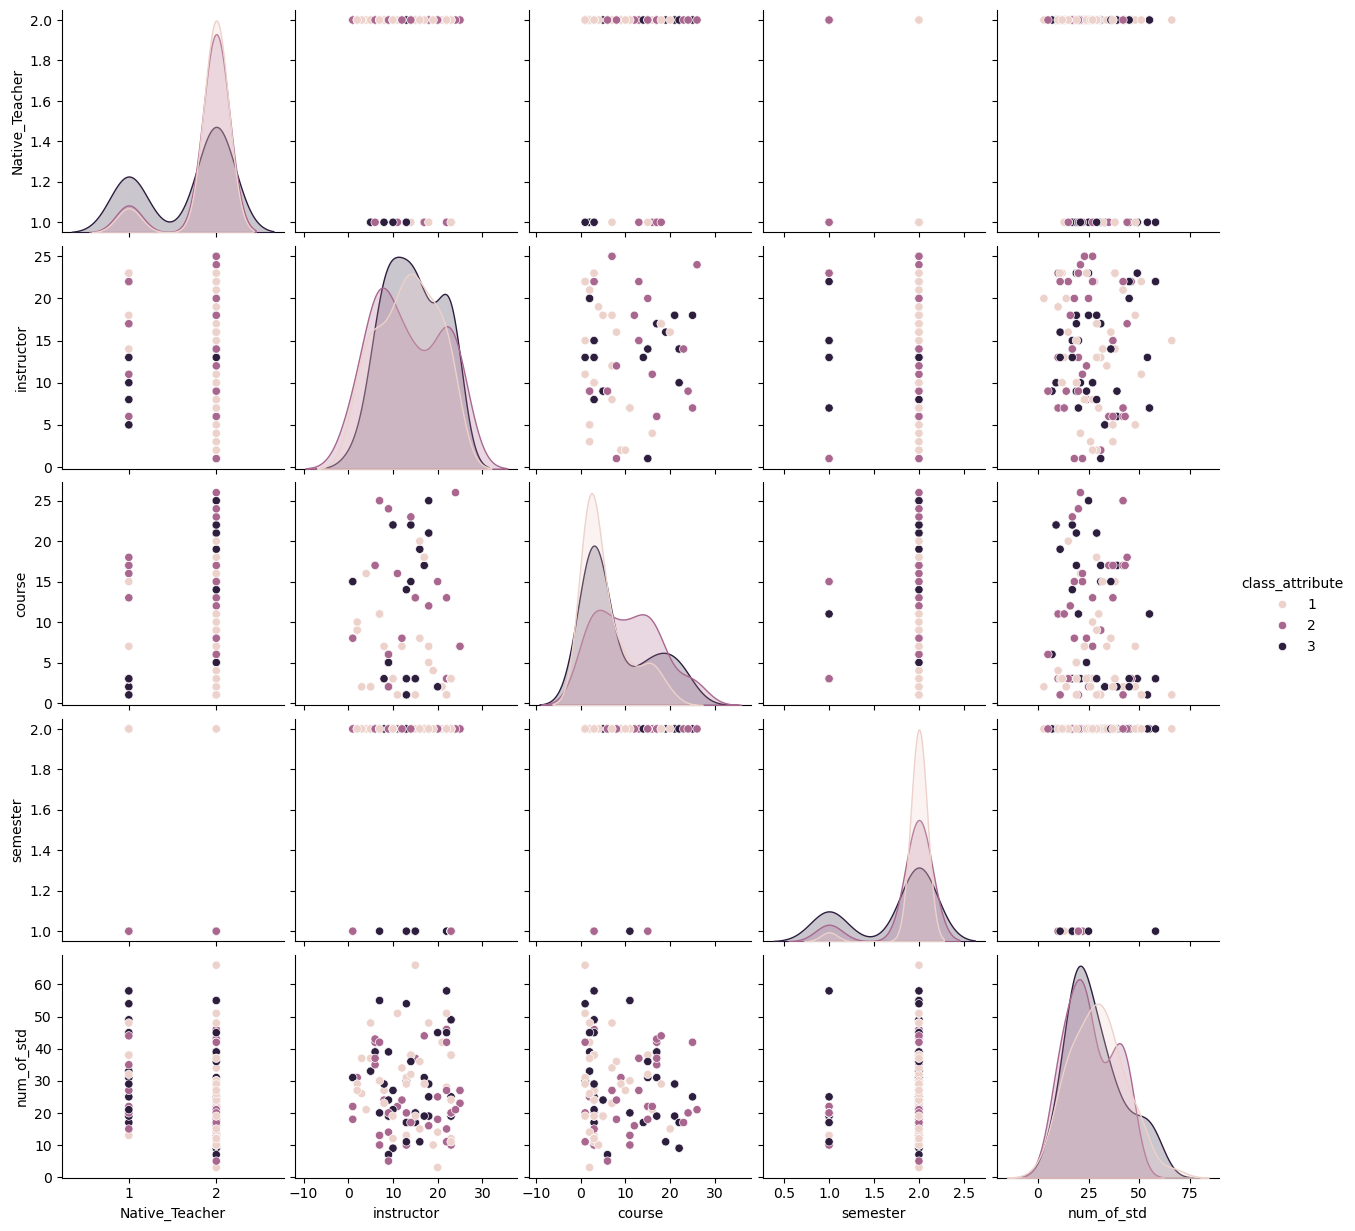

In [24]:
sns.pairplot(df,hue='class_attribute')

<Axes: xlabel='Native_Teacher', ylabel='class_attribute'>

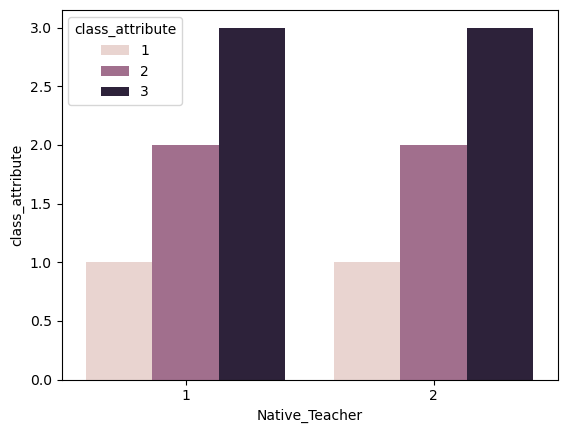

In [25]:
sns.barplot(x='Native_Teacher',y='class_attribute',hue='class_attribute',data=df)

<Axes: xlabel='Native_Teacher'>

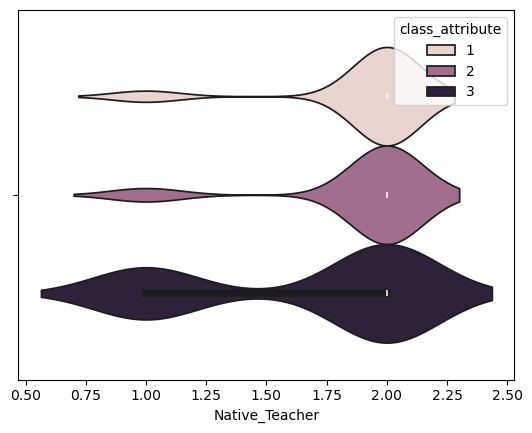

In [26]:
sns.violinplot(x='Native_Teacher', hue='class_attribute', data=df)

<Axes: xlabel='instructor', ylabel='count'>

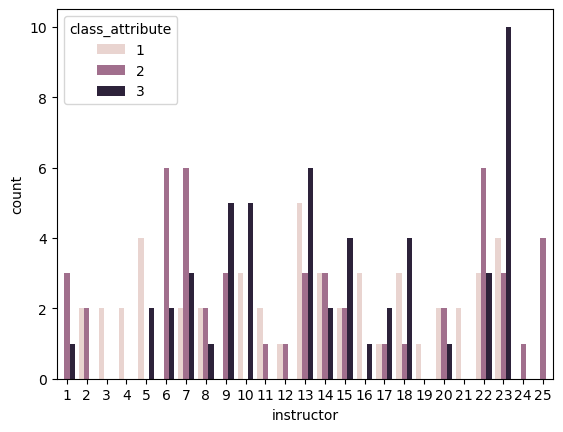

In [27]:
sns.countplot(x='instructor',hue='class_attribute',data=df)

<Axes: xlabel='course', ylabel='count'>

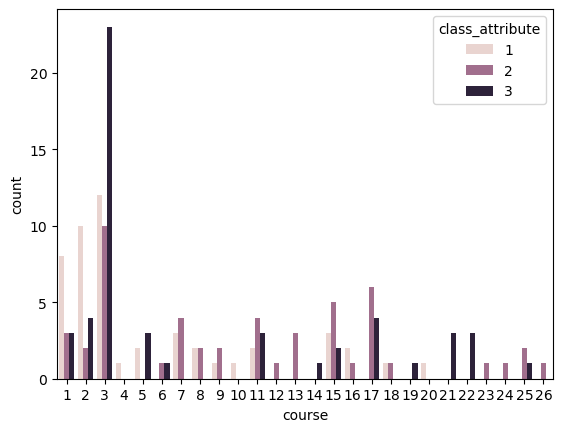

In [28]:
sns.countplot(x='course',hue='class_attribute',data=df)

<Axes: xlabel='semester', ylabel='count'>

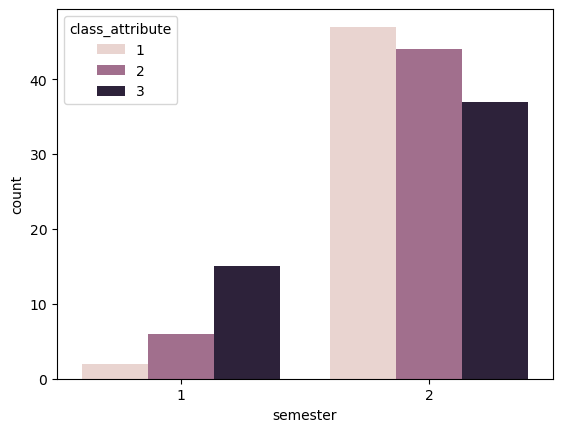

In [29]:
sns.countplot(x='semester',hue='class_attribute',data=df)

<Axes: xlabel='num_of_std', ylabel='count'>

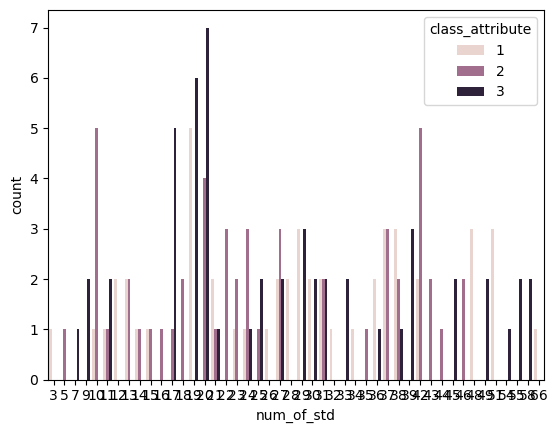

In [30]:
sns.countplot(x='num_of_std',hue='class_attribute',data=df)

<Axes: xlabel='num_of_std', ylabel='Count'>

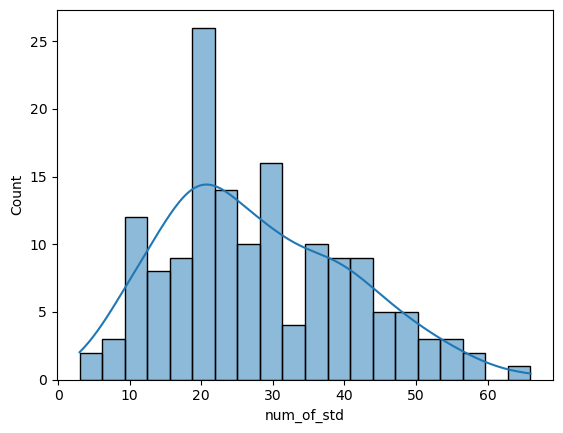

In [31]:
sns.histplot(df['num_of_std'],bins=20,kde=True)

<Axes: >

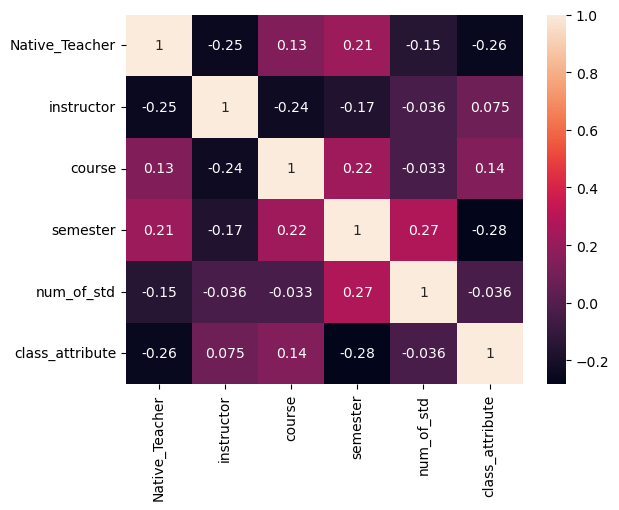

In [32]:
sns.heatmap(df.corr(),annot=True)

## Spliting the dataset

In [33]:
x=df.drop('class_attribute',axis=1)
y=df['class_attribute']

In [34]:
x.shape

(151, 5)

In [35]:
y.shape

(151,)

In [37]:
pip install scikit_learn

Note: you may need to restart the kernel to use updated packages.


In [38]:
from sklearn.model_selection import train_test_split

In [39]:
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=42)

In [40]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((120, 5), (31, 5), (120,), (31,))

In [41]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler


categorical_features = ['Native_Teacher','instructor','course','semester']
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
x_train_cat = encoder.fit_transform(x_train[categorical_features])
x_test_cat = encoder.transform(x_test[categorical_features])


x_train_num = x_train[['num_of_std']].values
x_test_num = x_test[['num_of_std']].values

x_train_final = np.hstack([x_train_cat, x_train_num])
x_test_final = np.hstack([x_test_cat, x_test_num])


In [42]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_final)
x_test_scaled = scaler.transform(x_test_final)

## Model using logistic regression 

In [52]:
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create logistic regression model and fit it
logreg = LogisticRegression()
logreg.fit(x_train_scaled , y_train)

# Make a Predictions
y_test_pred =logreg.predict(x_test_scaled)

# Evaluate model
accuracy = accuracy_score(y_test , y_test_pred)
print('Accuracy:',accuracy)

cm = confusion_matrix(y_test , y_test_pred)
print('Confusion Matrix:',cm)

cr = classification_report(y_test , y_test_pred)
print('Classification:',cr)

Accuracy: 0.6129032258064516
Confusion Matrix: [[8 3 0]
 [5 5 1]
 [1 2 6]]
Classification:               precision    recall  f1-score   support

           1       0.57      0.73      0.64        11
           2       0.50      0.45      0.48        11
           3       0.86      0.67      0.75         9

    accuracy                           0.61        31
   macro avg       0.64      0.62      0.62        31
weighted avg       0.63      0.61      0.61        31



## Model using SVM 

In [53]:
from sklearn.svm import SVC 
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report

## Create a SVM model and fit
svm= SVC(kernel='linear')     ##you can change the kernel type (e.g., 'rbf')
svm.fit(x_train_scaled , y_train)

## Make Predictions 
y_test_pred = svm.predict(x_test_scaled)

## Evaluate the model
accuracy = accuracy_score(y_test , y_test_pred)
print('Accuracy:',accuracy)

cm = confusion_matrix(y_test, y_test_pred)
print('Confusion Matrix:', cm)

cr = classification_report(y_test , y_test_pred)
print('Classification Report:',cr)


Accuracy: 0.6451612903225806
Confusion Matrix: [[9 2 0]
 [5 6 0]
 [1 3 5]]
Classification Report:               precision    recall  f1-score   support

           1       0.60      0.82      0.69        11
           2       0.55      0.55      0.55        11
           3       1.00      0.56      0.71         9

    accuracy                           0.65        31
   macro avg       0.72      0.64      0.65        31
weighted avg       0.70      0.65      0.65        31



### Model using Gradient Boosting Classifier

In [54]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report

## Create GradientBoostingClassifier and fit it 
gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gbc.fit(x_train_final , y_train)

## Make Predictions 
y_test_pred=gbc.predict(x_test_final)


## Evaluate the model 
accuracy = accuracy_score(y_test_pred , y_test)
print('Accuracy Score:', accuracy)

cm = confusion_matrix(y_test_pred , y_test)
print('Confusion Matrix:',cm)

cr = classification_report(y_test_pred , y_test)
print('Classification Report:', cr)


Accuracy Score: 0.7741935483870968
Confusion Matrix: [[ 9  0  2]
 [ 2 10  2]
 [ 0  1  5]]
Classification Report:               precision    recall  f1-score   support

           1       0.82      0.82      0.82        11
           2       0.91      0.71      0.80        14
           3       0.56      0.83      0.67         6

    accuracy                           0.77        31
   macro avg       0.76      0.79      0.76        31
weighted avg       0.81      0.77      0.78        31



## Model using Decision Tree

In [55]:
from sklearn.tree import DecisionTreeClassifier

# Initialize model
dt_model = DecisionTreeClassifier(random_state=42,class_weight='balanced')

# Fit the model
dt_model.fit(x_train_scaled, y_train)

# Predict on test set
y_pred_dt = dt_model.predict(x_test_scaled)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("Classification Report:\n", classification_report(y_test, y_pred_dt))

Accuracy: 0.7096774193548387
Confusion Matrix:
 [[9 2 0]
 [3 7 1]
 [1 2 6]]
Classification Report:
               precision    recall  f1-score   support

           1       0.69      0.82      0.75        11
           2       0.64      0.64      0.64        11
           3       0.86      0.67      0.75         9

    accuracy                           0.71        31
   macro avg       0.73      0.71      0.71        31
weighted avg       0.72      0.71      0.71        31



# model using random forest

In [56]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialize model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Fit the model
rf_model.fit(x_train_final, y_train)

# Predict on test set
y_pred_rt = rf_model.predict(x_test_final)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred_rt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rt))
print("Classification Report:\n", classification_report(y_test, y_pred_rt))

Accuracy: 0.7096774193548387
Confusion Matrix:
 [[11  0  0]
 [ 3  7  1]
 [ 2  3  4]]
Classification Report:
               precision    recall  f1-score   support

           1       0.69      1.00      0.81        11
           2       0.70      0.64      0.67        11
           3       0.80      0.44      0.57         9

    accuracy                           0.71        31
   macro avg       0.73      0.69      0.68        31
weighted avg       0.72      0.71      0.69        31



## Model using KNN

In [57]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialize model
knn_model = KNeighborsClassifier(n_neighbors=5)  # You can try 3, 7, etc.

# Fit the model
knn_model.fit(x_train_scaled, y_train)

# Predict on test set
y_pred_knn = knn_model.predict(x_test_scaled)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))
print("Classification Report:\n", classification_report(y_test, y_pred_knn))

Accuracy: 0.3870967741935484
Confusion Matrix:
 [[8 3 0]
 [8 2 1]
 [5 2 2]]
Classification Report:
               precision    recall  f1-score   support

           1       0.38      0.73      0.50        11
           2       0.29      0.18      0.22        11
           3       0.67      0.22      0.33         9

    accuracy                           0.39        31
   macro avg       0.44      0.38      0.35        31
weighted avg       0.43      0.39      0.35        31



## Model using ADA BoostClassifier

In [58]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialize model
ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)

# Fit the model
ada_model.fit(x_train_final, y_train)

# Predict
y_pred_ab = ada_model.predict(x_test_final)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred_ab))
print("Confusion Matrix:", confusion_matrix(y_test, y_pred_ab))
print("Classification Report:", classification_report(y_test, y_pred_ab))

Accuracy: 0.6129032258064516
Confusion Matrix: [[7 4 0]
 [4 7 0]
 [2 2 5]]
Classification Report:               precision    recall  f1-score   support

           1       0.54      0.64      0.58        11
           2       0.54      0.64      0.58        11
           3       1.00      0.56      0.71         9

    accuracy                           0.61        31
   macro avg       0.69      0.61      0.63        31
weighted avg       0.67      0.61      0.62        31



In [59]:
print("🏆 Best Model: GradientBoostingClassifier ")
print("Accuracy:", round(accuracy_score(y_test, y_test_pred), 4))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("Classification Report:\n", classification_report(y_test, y_test_pred))

🏆 Best Model: GradientBoostingClassifier 
Accuracy: 0.7742
Confusion Matrix:
 [[ 9  2  0]
 [ 0 10  1]
 [ 2  2  5]]
Classification Report:
               precision    recall  f1-score   support

           1       0.82      0.82      0.82        11
           2       0.71      0.91      0.80        11
           3       0.83      0.56      0.67         9

    accuracy                           0.77        31
   macro avg       0.79      0.76      0.76        31
weighted avg       0.79      0.77      0.77        31



## Hyperparameter Tuning in Best Model (GradientBoostingClassifier)

In [60]:
## Using GridSearchCV

from sklearn.model_selection import GridSearchCV

In [69]:
## Hyperparameter grid to search

param_grid ={ 'n_estimators':[100,250,500],
             'subsample' : [0.8,1.0],
             'min_samples_split':[2,5],
             'min_samples_leaf':[1,3] }

## Create a model and fit it
gb_cv = GridSearchCV(estimator=gbc,param_grid=param_grid , cv=5 , scoring='accuracy' , n_jobs=-1 , verbose=2)
gb_cv.fit(x_train_final , y_train )


Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'min_samples_leaf': [1, 3],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 250, 500],
                         'subsample': [0.8, 1.0]},
             scoring='accuracy', verbose=2)

In [71]:
gb_cv.best_params_

{'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 500,
 'subsample': 1.0}

In [72]:
print(gb_cv.best_score_)

0.5666666666666667


In [82]:
## predict
y_test_pred= gb_cv.predict(x_test_final)

print('Accuracy:',accuracy_score(y_test_pred , y_test))


print('Confusion Matrix:',confusion_matrix(y_test_pred , y_test))


print('Classification Report:',classification_report(y_test_pred , y_test))

Accuracy: 0.8064516129032258
Confusion Matrix: [[10  0  1]
 [ 1 10  3]
 [ 0  1  5]]
Classification Report:               precision    recall  f1-score   support

           1       0.91      0.91      0.91        11
           2       0.91      0.71      0.80        14
           3       0.56      0.83      0.67         6

    accuracy                           0.81        31
   macro avg       0.79      0.82      0.79        31
weighted avg       0.84      0.81      0.81        31



## Report

##  Objective:

The main goal of this project is to analyze the Teaching Assistant Evaluation dataset and build different Machine Learning models to predict the Class Attribute (Teaching Performance) based on several input features.

##  1. Data Loading and Understanding

The dataset (tae.csv) was loaded using Pandas.

It contains 6 columns with no header, so we renamed them for better understanding:

Native_Teacher – Whether the TA is a native English speaker (1 or 2)

Instructor – The course instructor ID

Course – The course number

Semester – Whether it is a summer or regular semester (1 or 2)

Num_of_Students – Number of students in the class

Class_Attribute – The overall teaching performance (target variable)

##  2. Data Exploration

Checked data types, null values, and duplicates.

The dataset had no missing values and no duplicates.

Used .describe() to find the statistical summary of numerical data.

Used .value_counts() to understand how data is distributed in each column.

##  3. Data Visualization

Visualized the dataset using Seaborn and Matplotlib to understand relationships between features and the target variable.

Count Plots: Showed how different categories (like Native_Teacher, Instructor, Course, etc.) relate to teaching performance.

Pair Plot: Displayed the pairwise relationships among all variables.

Bar Plot: Compared each teacher’s performance visually.

Histogram: Displayed the distribution of the number of students in classes.

Heatmap: Checked correlations between numerical variables.

 These visualizations helped us understand patterns in teaching performance and relationships among features.

##  4. Data Preprocessing

To prepare the data for machine learning models:

Categorical Columns: Used OneHotEncoder to convert categorical data (like Native_Teacher, Instructor, Course, Semester) into numerical form.

Numerical Column: Kept Num_of_Students as it is.

Feature Scaling: Used StandardScaler to normalize all feature values for better model performance.

Train-Test Split: Divided data into 80% training and 20% testing using train_test_split.

##  5. Model Building

Several machine learning models were trained and compared to find the best one.


##  6. Best Model Selection

After comparing all models, Gradient Boosting Classifier was found to perform the best with the highest accuracy and consistent performance across all evaluation metrics.

It gave a balanced classification performance for all teaching performance classes.

## 7. Hyperparameter Tuning

To further improve the model, GridSearchCV was applied to tune the hyperparameters of the Gradient Boosting model.


## 8. Evaluation Metrics Used

Accuracy Score – Measures the percentage of correct predictions.

Confusion Matrix – Shows how many predictions were correct and incorrect for each class.

Classification Report – Provides precision, recall, and F1-score for each class.

MAE, MSE, RMSE, R² – Used for regression model evaluation.

## 9. Final Results Summary

Model	Type	Performance Summary
Logistic Regression	Classification	Moderate accuracy
SVM (Linear Kernel)	Classification	Good, but slower
Decision Tree	Classification	Overfitting risk
Random Forest	Classification	Good accuracy
KNN	Classification	Moderate accuracy
AdaBoost	Classification	Good accuracy
Gradient Boosting (Best)	Classification	Highest accuracy and reliable results

## 10. Conclusion

The Gradient Boosting Classifier performed the best among all models.

Hyperparameter tuning improved its performance even further.

Data preprocessing (encoding and scaling) played an important role in improving accuracy.

Visualization and exploration helped understand how teaching attributes affect performance.